In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('tr_server_data.csv',header=None)
df.head()

,0,1
0,13.047,14.741
1,13.409,13.763
2,14.196,15.853
3,14.915,16.174
4,13.577,14.043


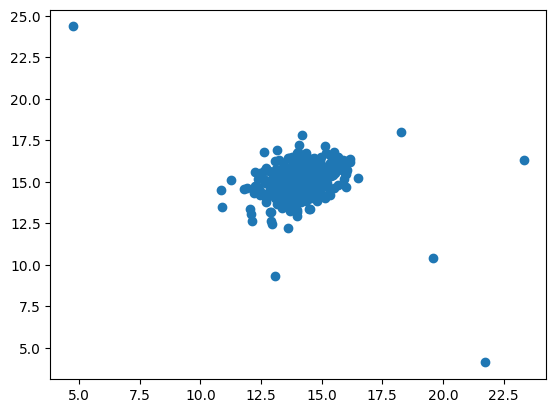

In [3]:
plt.scatter(df.iloc[:,0],df.iloc[:,1])

In [4]:
from sklearn.neighbors import LocalOutlierFactor

In [7]:
best_score = -1
best_params = {}

for n in [5, 10, 20, 30, 50]:
    for contamination in [0.01, 0.05, 0.1]:
        model = LocalOutlierFactor(
            n_neighbors=n,
            contamination=contamination
        )

        y_pred = model.fit_predict(df)

     

In [8]:
y_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,
        1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1, -1,  1,  1

In [9]:
model.n_neighbors_

50

In [10]:
model.get_params

<bound method BaseEstimator.get_params of LocalOutlierFactor(contamination=0.1, n_neighbors=50)>

In [11]:
model.novelty

False

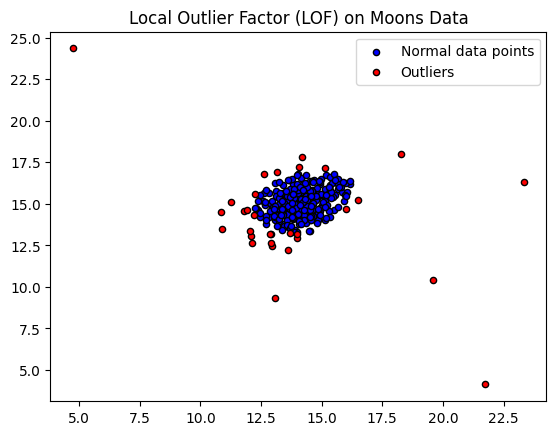

In [13]:
# Separate normal data points>>inliers and outliers 
X_inliers = df[y_pred == 1]
X_outliers = df[y_pred == -1]

# Plotting

# Plotting
plt.title("Local Outlier Factor (LOF) on Moons Data")
plt.scatter(X_inliers.iloc[:, 0], X_inliers.iloc[:, 1], color='b', s=20, edgecolor='k', label='Normal data points')
plt.scatter(X_outliers.iloc[:, 0], X_outliers.iloc[:, 1], color='r', s=20, edgecolor='k', label='Outliers')
plt.legend()
plt.show()